# Explorative Datenanalyse: Kundenabwanderung (Churn)

Ziel: verstehen, welche Merkmale mit Abwanderung zusammenhaengen, bevor ein
Vorhersagemodell gebaut wird. Datenquelle ist die MySQL-Tabelle `customers`
(befuellt in Etappe 2), nicht die CSV-Datei.


In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from matplotlib.colors import LinearSegmentedColormap
from sqlalchemy import create_engine, text

# display() ist eine IPython-Funktion, in Jupyter automatisch verfuegbar
# (anders als print zeigt sie DataFrames als formatierte Tabelle).

# Eine Akzentfarbe (Blau) fuer Kennzahlen, Grau als neutraler Vergleichswert -
# bewusst kein Regenbogen aus Matplotlib-Standardfarben.
ACCENT = "#2a78d6"
NEUTRAL = "#898781"

sns.set_style("white")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.axis"] = "y"
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["grid.linewidth"] = 0.8
plt.rcParams["font.size"] = 11
# Ergebnis: einheitlicher, schlichter Stil fuer alle Diagramme in diesem Notebook gesetzt.


In [2]:
# .env liegt eine Ebene ueber dem Notebook (analytics/.env), Zugangsdaten
# kommen nicht in den Code.
ENV_PATH = Path("..") / ".env"
load_dotenv(ENV_PATH)

url = (
    f"mysql+pymysql://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}"
)
engine = create_engine(url)

# CAST auf UNSIGNED, weil MySQL churn als bit(1) liefert - als rohe bytes waere
# b'\x00' (False) in Python truthy und wuerde jede Auswertung verfaelschen.
query = text(
    """
    SELECT
        customer_id, contract, payment_method, internet_service,
        tenure, monthly_charges, total_charges,
        CAST(churn AS UNSIGNED) AS churn
    FROM customers
    """
)
df = pd.read_sql(query, engine)
df.shape
# Ergebnis: 7043 Kunden mit 8 geladenen Spalten, deckt sich mit dem CSV-Import aus Etappe 2.


(7043, 8)

## 1. Churn-Rate insgesamt und Klassenverteilung

In [3]:
klassenverteilung = df["churn"].value_counts().rename({0: "Nein", 1: "Ja"})
churn_rate = df["churn"].mean()

print(f"Churn-Rate insgesamt: {churn_rate:.1%}")
klassenverteilung
# Ergebnis: Jeder vierte Kunde (26,5 %, 1869 von 7043) hat gekuendigt - die Klassen
# sind unausgeglichen, das ist bei Etappe 5 (Modell) zu beruecksichtigen.


Churn-Rate insgesamt: 26.5%


churn
Nein    5174
Ja      1869
Name: count, dtype: int64

## 2. Churn-Rate nach Vertragsart, Zahlungsmethode und Internetdienst

,churn_rate,anzahl
contract,,
Month-to-month,0.427,3875
One year,0.113,1473
Two year,0.028,1695


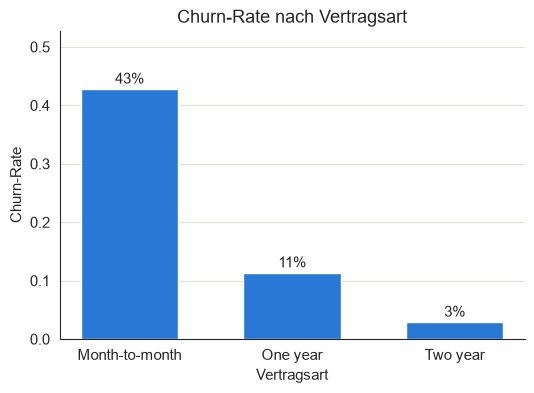

In [4]:
nach_vertrag = (
    df.groupby("contract")["churn"]
    .agg(churn_rate="mean", anzahl="count")
    .sort_values("churn_rate", ascending=False)
)
display(nach_vertrag.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(nach_vertrag.index, nach_vertrag["churn_rate"], color=ACCENT, width=0.6)
for i, wert in enumerate(nach_vertrag["churn_rate"]):
    ax.text(i, wert + 0.01, f"{wert:.0%}", ha="center")
ax.set_xlabel("Vertragsart")
ax.set_ylabel("Churn-Rate")
ax.set_title("Churn-Rate nach Vertragsart")
ax.set_ylim(0, nach_vertrag["churn_rate"].max() + 0.1)
plt.show()
# Ergebnis: Month-to-month kuendigt mit 42,7 % mehr als 15x so oft wie Two-year (2,8 %) -
# die Vertragsbindung ist der staerkste erkennbare Hebel gegen Abwanderung.


,churn_rate,anzahl
payment_method,,
Electronic check,0.453,2365
Mailed check,0.191,1612
Bank transfer (automatic),0.167,1544
Credit card (automatic),0.152,1522


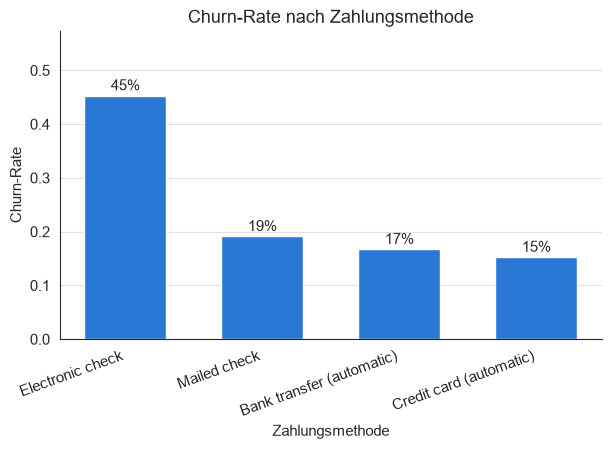

In [5]:
nach_zahlungsmethode = (
    df.groupby("payment_method")["churn"]
    .agg(churn_rate="mean", anzahl="count")
    .sort_values("churn_rate", ascending=False)
)
display(nach_zahlungsmethode.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(nach_zahlungsmethode.index, nach_zahlungsmethode["churn_rate"], color=ACCENT, width=0.6)
for i, wert in enumerate(nach_zahlungsmethode["churn_rate"]):
    ax.text(i, wert + 0.01, f"{wert:.0%}", ha="center")
ax.set_xlabel("Zahlungsmethode")
ax.set_ylabel("Churn-Rate")
ax.set_title("Churn-Rate nach Zahlungsmethode")
ax.set_ylim(0, nach_zahlungsmethode["churn_rate"].max() + 0.12)
plt.xticks(rotation=20, ha="right")
plt.show()
# Ergebnis: Electronic Check kuendigt mit 45,3 % mit Abstand am haeufigsten,
# automatische Zahlungsarten liegen deutlich niedriger bei rund 15-17 %.


,churn_rate,anzahl
internet_service,,
Fiber optic,0.419,3096
DSL,0.190,2421
No,0.074,1526


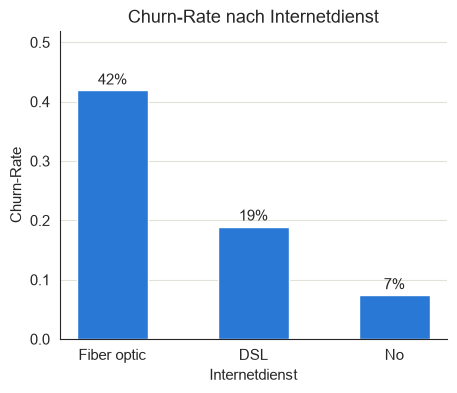

In [6]:
nach_internetdienst = (
    df.groupby("internet_service")["churn"]
    .agg(churn_rate="mean", anzahl="count")
    .sort_values("churn_rate", ascending=False)
)
display(nach_internetdienst.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(nach_internetdienst.index, nach_internetdienst["churn_rate"], color=ACCENT, width=0.5)
for i, wert in enumerate(nach_internetdienst["churn_rate"]):
    ax.text(i, wert + 0.01, f"{wert:.0%}", ha="center")
ax.set_xlabel("Internetdienst")
ax.set_ylabel("Churn-Rate")
ax.set_title("Churn-Rate nach Internetdienst")
ax.set_ylim(0, nach_internetdienst["churn_rate"].max() + 0.1)
plt.show()
# Ergebnis: Fiber-optic-Kunden kuendigen mit 41,9 % ueber fuenfmal so oft wie
# Kunden ohne Internetdienst (7,4 %).


## 3. Verteilung von tenure und monthlyCharges, getrennt nach Churn

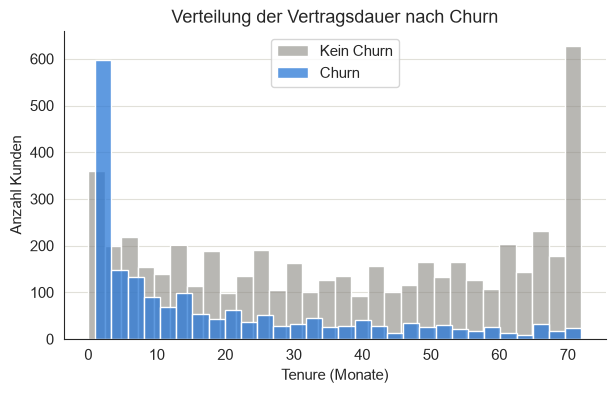

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df.loc[df["churn"] == 0, "tenure"], color=NEUTRAL, label="Kein Churn", alpha=0.6, bins=30, ax=ax)
sns.histplot(df.loc[df["churn"] == 1, "tenure"], color=ACCENT, label="Churn", alpha=0.75, bins=30, ax=ax)
ax.set_xlabel("Tenure (Monate)")
ax.set_ylabel("Anzahl Kunden")
ax.set_title("Verteilung der Vertragsdauer nach Churn")
ax.legend()
plt.show()
# Ergebnis: Abwanderer kuendigen typischerweise frueh (Median 10 Monate) gegenueber
# 38 Monaten bei Bleibern - die churn-Verteilung ist deutlich nach links verschoben.


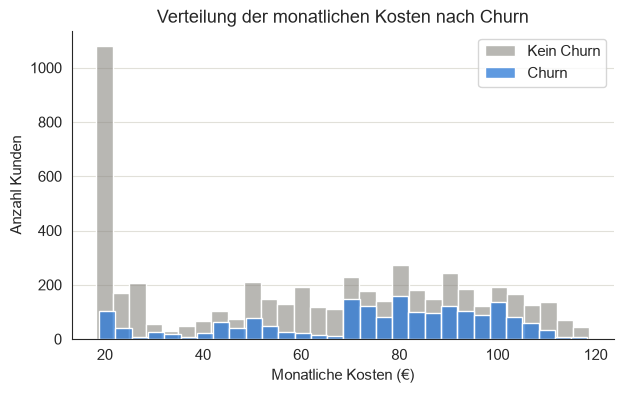

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df.loc[df["churn"] == 0, "monthly_charges"], color=NEUTRAL, label="Kein Churn", alpha=0.6, bins=30, ax=ax)
sns.histplot(df.loc[df["churn"] == 1, "monthly_charges"], color=ACCENT, label="Churn", alpha=0.75, bins=30, ax=ax)
ax.set_xlabel("Monatliche Kosten (€)")
ax.set_ylabel("Anzahl Kunden")
ax.set_title("Verteilung der monatlichen Kosten nach Churn")
ax.legend()
plt.show()
# Ergebnis: Abwanderer haeufen sich staerker im oberen Preisbereich, Bleiber vor
# allem im unteren Bereich um die 20 € (viele reine Telefon-Kunden ohne Internet).


## 4. Durchschnittlicher Monatsumsatz: Abwanderer vs. Bleiber

churn
Kein Churn    61.27
Churn         74.44
Name: monthly_charges, dtype: float64

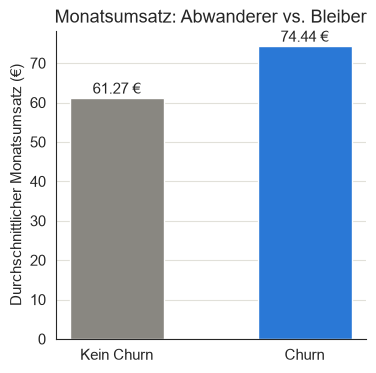

In [9]:
monatsumsatz_nach_churn = (
    df.groupby("churn")["monthly_charges"].mean().rename({0: "Kein Churn", 1: "Churn"})
)
display(monatsumsatz_nach_churn.round(2))

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(monatsumsatz_nach_churn.index, monatsumsatz_nach_churn.values, color=[NEUTRAL, ACCENT], width=0.5)
for i, wert in enumerate(monatsumsatz_nach_churn.values):
    ax.text(i, wert + 1, f"{wert:.2f} €", ha="center")
ax.set_ylabel("Durchschnittlicher Monatsumsatz (€)")
ax.set_title("Monatsumsatz: Abwanderer vs. Bleiber")
plt.show()
# Ergebnis: Abwanderer zahlen im Schnitt 74,44 € statt 61,27 € - rund 22 % mehr
# als Bleiber. Abwanderung ist also kein Sparkunden-Phaenomen.


## 5. Gesamter Monatsumsatz, der an abgewanderten Kunden haengt

In [10]:
umsatz_abgewandert = df.loc[df["churn"] == 1, "monthly_charges"].sum()
umsatz_gesamt = df["monthly_charges"].sum()
anteil = umsatz_abgewandert / umsatz_gesamt

print(f"Monatsumsatz an abgewanderten Kunden: {umsatz_abgewandert:,.2f} EUR")
print(f"Anteil am gesamten Monatsumsatz: {anteil:.1%}")
# Ergebnis: 139.130,85 EUR Monatsumsatz haengen an bereits abgewanderten Kunden,
# das sind 30,5 % des gesamten Monatsumsatzes - deutlich mehr als der 26,5%-Anteil
# an Kunden, weil Abwanderer im Schnitt teurere Tarife hatten.


Monatsumsatz an abgewanderten Kunden: 139,130.85 EUR
Anteil am gesamten Monatsumsatz: 30.5%


## 6. Korrelation der numerischen Merkmale mit Churn

tenure            -0.352
total_charges     -0.198
monthly_charges    0.193
Name: churn, dtype: float64

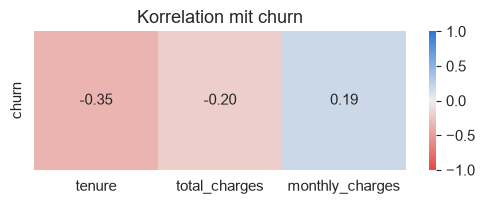

In [11]:
# Nur echte Zahlenfelder (Integer/BigDecimal im Schema) - die Yes/No-Felder sind
# kategorisch und muessten erst kodiert werden.
numerische_spalten = ["tenure", "monthly_charges", "total_charges"]
korrelation = df[numerische_spalten + ["churn"]].corr()["churn"].drop("churn").sort_values()
display(korrelation.round(3))

# Diverging Blau/Rot ueber neutralem Grau, weil die Korrelation ein Vorzeichen hat -
# eine einzelne Akzentfarbe wuerde positiv und negativ nicht unterscheidbar machen.
diverging_cmap = LinearSegmentedColormap.from_list("blau_rot", ["#e34948", "#f0efec", "#2a78d6"])

fig, ax = plt.subplots(figsize=(6, 1.8))
sns.heatmap(
    korrelation.to_frame().T, annot=True, fmt=".2f", cmap=diverging_cmap,
    center=0, vmin=-1, vmax=1, cbar=True, ax=ax, yticklabels=["churn"],
)
ax.set_title("Korrelation mit churn")
plt.show()
# Ergebnis: tenure haengt am staerksten mit churn zusammen (-0,35, je laenger Kunde,
# desto seltener Kuendigung), gefolgt von totalCharges (-0,20) und monthlyCharges (+0,19).


## Zusammenfassung: die fünf wichtigsten Erkenntnisse

1. **Die Vertragsart ist der stärkste Hebel.** Month-to-month-Kunden kündigen mit
   42,7 % über 15-mal so oft wie Kunden mit Zwei-Jahres-Vertrag (2,8 %).
2. **Zahlungsart und Internetdienst zeigen ein ähnliches Risikomuster.**
   Electronic Check (45,3 %) und Fiber-optic (41,9 %) sind die Segmente mit der
   höchsten Abwanderung - beides Merkmale ohne feste Bindung an das Unternehmen.
3. **Abwanderer kündigen früh.** Median-Vertragsdauer 10 Monate gegenüber 38
   Monaten bei Bleibern; tenure ist mit -0,35 auch numerisch am stärksten mit
   churn korreliert - stärker als monthlyCharges (+0,19) oder totalCharges (-0,20).
4. **Abwanderer sind keine Sparkunden.** Sie zahlen im Schnitt 74,44 € statt
   61,27 € monatlich (rund 22 % mehr) - Abwanderung betrifft überdurchschnittlich
   teure Kunden, nicht in erster Linie Kleinkunden.
5. **Der wirtschaftliche Schaden ist erheblich.** 139.130,85 € Monatsumsatz
   (30,5 % des gesamten Monatsumsatzes) hängen bereits an abgewanderten Kunden -
   ein höherer Anteil als ihr Kundenanteil (26,5 %), eben weil sie im Schnitt
   teurere Tarife hatten.
